In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.min_features import min_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

# pos = pd.read_csv('data/raw/player_positions/player_positions.csv')
# s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
132,2025-26,1630536,Sharife Cooper,Sharife,1610612764,WAS,Washington Wizards,22501087,2026-03-29T00:00:00,WAS @ POR,L,19.000000,4,9,0.444,0,1,0.000,2,2,1.000,0,1,1,2,2,0,0,0,1,2,10,-11,12.2,0,0,13.0,1,19:00,1,90.4,90.0,90.0,121.8,120.5,120.5,-31.4,-30.5,-30.5,0.250,1.0,14.3,0.000,0.056,0.027,14.3,14.4,0.444,0.506,0.279,0.291,99.08,99.79,83.16,99.79,0.077,40,4.0,9.0,32,87,0.368,5,22,0.227,19,22,0.864,9,30,39,16,16.0,7,2,10,28,24,88,-35.0,84.9,85.4,119.3,119.4,-34.4,-34.0,0.500,1.00,12.1,0.232,0.696,0.441,0.155,0.397,0.455,103.4,103.0,85.83,103,0.280,1610612757,POR,Portland Trail Blazers,44,86,0.512,12,36,0.333,23,32,0.719,11,38,49,24,14.0,8,10,2,24,28,123,35.0,119.3,119.4,84.9,85.4,34.4,34.0,0.545,1.71,17.0,0.304,0.768,0.559,0.136,0.581,0.615,103.4,103.0,85.83,103,0.720,NaN,PG,24.0,0
131,2025-26,1630264,Anthony Gill,Anthony,1610612764,WAS,Washington Wizards,22501087,2026-03-29T00:00:00,WAS @ POR,L,30.600000,4,7,0.571,0,1,0.000,0,0,0.000,0,3,3,0,2,1,0,1,4,1,8,-34,12.6,0,0,13.0,1,30:36,1,77.0,76.5,76.5,130.2,128.4,128.4,-53.2,-51.9,-51.9,0.000,0.0,0.0,0.000,0.103,0.049,22.2,22.2,0.571,0.571,0.122,0.126,104.75,105.88,88.24,105.88,0.026,68,4.0,7.0,32,87,0.368,5,22,0.227,19,22,0.864,9,30,39,16,16.0,7,2,10,28,24,88,-35.0,84.9,85.4,119.3,119.4,-34.4,-34.0,0.500,1.00,12.1,0.232,0.696,0.441,0.155,0.397,0.455,103.4,103.0,85.83,103,0.280,1610612757,POR,Portland Trail Blazers,44,86,0.512,12,36,0.333,23,32,0.719,11,38,49,24,14.0,8,10,2,24,28,123,35.0,119.3,119.4,84.9,85.4,34.4,34.0,0.545,1.71,17.0,0.304,0.768,0.559,0.136,0.581,0.615,103.4,103.0,85.83,103,0.720,NaN,PF,33.0,0
130,2025-26,1629021,Moritz Wagner,Moritz,1610612753,ORL,Orlando Magic,22501086,2026-03-29T00:00:00,ORL @ TOR,L,12.000000,3,6,0.500,1,2,0.500,0,0,0.000,0,4,4,1,0,0,0,1,0,1,7,-7,13.3,0,0,13.0,1,12:00,1,73.1,70.4,70.4,100.5,100.0,100.0,-27.4,-29.6,-29.6,0.200,0.0,14.3,0.000,0.333,0.160,0.0,0.0,0.583,0.583,0.222,0.231,103.76,106.00,88.33,106.00,0.162,27,3.0,6.0,31,82,0.378,9,38,0.237,16,19,0.842,9,27,36,20,28.0,4,1,3,20,18,87,-52.0,79.6,83.7,129.1,132.4,-49.5,-48.7,0.645,0.71,14.4,0.283,0.705,0.474,0.269,0.433,0.481,108.5,104.5,87.08,104,0.195,1610612761,TOR,Toronto Raptors,54,94,0.574,13,29,0.448,18,22,0.818,7,37,44,41,11.0,20,3,1,18,20,139,52.0,129.1,132.4,79.6,83.7,49.5,48.7,0.759,3.73,25.8,0.295,0.717,0.526,0.105,0.644,0.670,108.5,104.5,87.08,105,0.805,NaN,C,28.0,0
141,2025-26,1631218,Tr

In [4]:
def apply_bayesian_minutes(df, confidence_k=20):
    """
    confidence_k: The 'strength' of the prior. 
    Equivalent to saying 'I want to act as if every player has 
    already played K games at the league average.'
    """
    
    # 1. Define the Global Priors based on Role (pos + STARTING)
    # This groups by Position and whether they are a Starter (1 or 0)
    priors = df.groupby(['pos', 'STARTING'])['MIN'].mean().to_dict()
    
    # 2. Calculate Player stats: Mean Minutes and Number of Games (Sample Size)
    player_stats = df.groupby('PLAYER_ID').agg(
        player_mean_min=('MIN', 'mean'),
        games_played=('MIN', 'count'))
    
    # 3. Merge back to the main dataframe
    df = df.merge(player_stats, on='PLAYER_ID', how='left')
    
    # 4. Map the Prior to each row
    df['prior_min'] = df.set_index(['pos', 'STARTING']).index.map(priors.get)
    
    # 5. The Bayesian Update Formula:
    # (n * player_mean + k * prior_mean) / (n + k)
    df['bayesian_min_proj'] =round(((df['games_played'] * df['player_mean_min']) + (confidence_k * df['prior_min'])) / (df['games_played'] + confidence_k), 2)
    
    return df['bayesian_min_proj']

In [ ]:
res = []
for df in [s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["BAYES_MIN_PROJ"] = apply_bayesian_minutes(df)
    df = min_features(df)
    df['TEAM_PTS_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_RANK_BY_POS_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['PTS_roll5']
    .rank(ascending=False, method='dense'))
    df['TEAM_POSS_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['POSS_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_POSS_RANK_BY_POS_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['POSS_roll5']
    .rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_BY_POS_L5'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['MIN_roll5']
    .rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll10']
    .rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PIE_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PIE_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L5'] = (df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll5'].rank(ascending=False, method='dense'))
    df['USG_EWM_L12'] = (df.groupby('PLAYER_ID')['USG_PCT'].transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean()))
    df['USG_EWM_L5'] = (df.groupby('PLAYER_ID')['USG_PCT'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_EWM_L12'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean()))
    df['MIN_EWM_L5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_EWM_L3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df['MEDIAN_MIN_L10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).median()))
    df['STARTER_X_MIN_AVG'] = df['STARTING'] * df['MIN_season_avg']
    df['AGE_X_B2B'] = df['age'] * df['IS_B2B']
    df['HOME_X_MIN_AVG'] = df['IS_HOME'] * df['MIN_season_avg']
    df['EXPECTED_MARGIN'] = (df['TEAM_NET_RATING_roll5'] - df['OPP_NET_RATING_roll5']).abs()
    df['MIN_MAX_L5'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(5).max())
    df['MIN_MIN_L5'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(5).min())
    df['HIGH_MIN_PLAYER'] = (df['MIN_roll10'] > 30).astype(int)
    df['HIGH_MIN_TIER'] = np.nan
    mask = df['MIN_EWM_L12'].notna()
    df.loc[mask, 'HIGH_MIN_TIER'] = pd.cut(
        df.loc[mask, 'MIN_EWM_L12'],
        bins=[0, 20, 25, 30, 34, 100],
        labels=[0, 1, 2, 3, 4],
        include_lowest=True,
    ).astype(int)
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])
    df['PLAYER_ENC'] = le.fit_transform(df['PLAYER_NAME'])
    df['ROLE_LOCK'] = (
    df['STARTER_ROLL10_PCT'] * df['MIN_std10'].apply(lambda x: 1/x))  # high start% + low variance = locked in role = safest bet
    df['ROLE_SHOCK'] = (
    df['MIN_EWM_L5'] - df['MIN_EWM_L12']          # short vs long term gap
    ) / df['MIN_EWM_L12']                            # normalized as % change
    df['PM_PER_MIN']    = df['PLUS_MINUS_lag1'] / df['MIN_lag1'].replace(0, np.nan)
    df['PM_PER_MIN_R10']= df['PM_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).mean())
    # df["MIN_ABOVE_35_L10"] = (
    # (df["MIN"] >= 35)
    # .groupby(df["PLAYER_ID"])
    # .shift(1)                       # exclude current game to avoid leakage
    # .rolling(10, min_periods=1)
    # .sum()
    # .reset_index(level=0, drop=True))
    
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 15).mean())
    eligible = player_avgs[player_avgs >= 0.50].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df[df['PLAYER_NAME'] == 'LeBron James']

(39245, 326)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING,BAYES_MIN_PROJ,MIN_roll3,PTS_roll3,REB_roll3,AST_PCT_roll3,OREB_PCT_roll3,DREB_PCT_roll3,TM_TOV_PCT_roll3,PLUS_MINUS_roll3,PF_roll3,POSS_roll3,PIE_roll3,USG_PCT_roll3,TS_PCT_roll3,NET_RATING_roll3,OFF_RATING_roll3,DEF_RATING_roll3,MIN_roll5,PTS_roll5,REB_roll5,AST_PCT_roll5,OREB_PCT_roll5,DREB_PCT_roll5,TM_TOV_PCT_roll5,PLUS_MINUS_roll5,PF_roll5,POSS_roll5,PIE_roll5,USG_PCT_roll5,TS_PCT_roll5,NET_RATING_roll5,OFF_RATING_roll5,DEF_RATING_roll5,MIN_roll10,PTS_roll10,REB_roll10,AST_PCT_roll10,OREB_PCT_roll10,DREB_PCT_roll10,TM_TOV_PCT_roll10,PLUS_MINUS_roll10,PF_roll10,POSS_roll10,PIE_roll10,USG_PCT_roll10,TS_PCT_roll10,NET_RATING_roll10,OFF_RATING_roll10,DEF_RATING_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,AST_lag1,REB_lag1,STL_lag1,BLK_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,AST_lag2,REB_lag2,STL_lag2,BLK_lag2,MIN_lag3,PTS_lag3,PLUS_MINUS_lag3,PIE_lag3,STARTING_lag3,POSS_lag3,USG_PCT_lag3,AST_lag3,REB_lag3,STL_lag3,BLK_lag3,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,REB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG_PCT_season_avg,FG3M_season_avg,FG3A_season_avg,FG3_PCT_season_avg,OREB_season_avg,DREB_season_avg,PLUS_MINUS_season_avg,PF_season_avg,POSS_season_avg,PIE_season_avg,USG_PCT_season_avg,TS_PCT_season_avg,NET_RATING_season_avg,TEAM_PACE_roll5,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,MIN_std5,MIN_std20,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_NET_RATING_roll5,OPP_NET_RATING_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,rot_group,exp_min,active_pos_min_sum,pos_cap,POS_VACANCY,PLAYER_POS_OPPORTUNITY,TEAM_PTS_RANK_L5,TEAM_PTS_RANK_BY_POS_L5,TEAM_POSS_RANK_L5,TEAM_POSS_RANK_BY_POS_L5,TEAM_MIN_RANK_L5,TEAM_MIN_RANK_BY_POS_L5,TEAM_USG_RANK_BY_POS_L10,TEAM_PIE_RANK_L5,TEAM_USG_RANK_L5,TEAM_USG_RANK_BY_POS_L5,USG_EWM_L12,USG_EWM_L5,MIN_EWM_L12,MIN_EWM_L5,MIN_EWM_L3,MEDIAN_MIN_L10,STARTER_X_MIN_AVG,AGE_X_B2B,HOME_X_MIN_AVG,EXPECTED_MARGIN,MIN_MAX_L5,MIN_MIN_L5,HIGH_MIN_PLAYER,HIGH_MIN_TIER,GP,POSITION_ENC,PLAYER_ENC,ROLE_LOCK,ROLE_SHOCK,PM_PER_MIN,PM_PER_MIN_R10
0,2024-25,2544,LeBron James,LeBron,1

1. Can create a model for players who average 5-20, and another for players who average 20-30 and lastly 30+

In [ ]:
MIN_FEATURES = [
    # Tier 1 — Core role
    'BAYES_MIN_PROJ',
    'STARTER_X_MIN_AVG',
    'MIN_EWM_L12',
    'MIN_EWM_L3',
    'STARTING_lag1',
    'STARTER_ROLL10_PCT',
    'ROLE_LOCK',
    'MEDIAN_MIN_L10',
    'MIN_MIN_L5',#new
    'MIN_MAX_L5',#new
    'HIGH_MIN_TIER',#new
    
    # Tier 2 — Team context
    'TEAM_MIN_RANK_L5',
    'TEAM_POSS_RANK_L5',
    'TEAM_PTS_RANK_L5',
    'TEAM_USG_RANK_L5',
    'POSS_roll5',

    # Tier 3 — Situational
    'DAYS_REST',
    'AGE_X_B2B',
    'USG_EWM_L5',
    'PM_PER_MIN_R10',
    'POSITION_ENC',
    'HOME_X_MIN_AVG',
    'MIN_share_proxy',
    'TEAM_POSS_RANK_BY_POS_L5',  # keep ONE by-pos feature
]

In [7]:
min_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna()

# -- TIME-BASED SPLIT --
split_date = min_df["GAME_DATE"].quantile(0.75)  # train on first 75% of season
train_mask = min_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train_min = min_df.loc[train_mask, MIN_FEATURES]
y_train_min = min_df.loc[train_mask, "MIN"]
X_val_min   = min_df.loc[val_mask, MIN_FEATURES]
y_val_min   = min_df.loc[val_mask, "MIN"]

# -- SETUP --
quantiles = [0.10, 0.50, 0.90]

quantile_models = {}
quantile_preds  = {}

for q in quantiles:
    q_float = float(q)
    key = f"q_{q_float:.2f}"
    print(f"Training model for Quantile: {key}...")

    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q_float,
        n_estimators=800,
        max_depth=8,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.01,
        reg_lambda=0.1,
        reg_alpha=0.1,
        random_state=42,
        n_jobs=-1,
    )

    xgb_q.fit(
        X_train_min,
        y_train_min,
        eval_set=[(X_val_min, y_val_min)],
        verbose=False,
    )

    quantile_models[key] = xgb_q
    quantile_preds[key]  = xgb_q.predict(X_val_min)

# -- EVALUATION --
results_df = X_val_min.copy()
results_df["Actual"]    = y_val_min.values
results_df["Lower_10"]  = quantile_preds["q_0.10"]
results_df["Median_50"] = quantile_preds["q_0.50"]
results_df["Upper_90"]  = quantile_preds["q_0.90"]

high_min_stars = results_df[results_df["Actual"] >= 35]

print("\n--- Performance on Players with 35+ Actual Minutes ---")
print(f"Average Actual: {high_min_stars['Actual'].mean():.2f}")
print(f"Avg Median Pred: {high_min_stars['Median_50'].mean():.2f}")
print(f"Avg Ceiling Pred (Q90): {high_min_stars['Upper_90'].mean():.2f}")

q50_mae = mean_absolute_error(y_val_min, quantile_preds["q_0.50"])
q50_rmse = np.sqrt(mean_squared_error(y_val_min, quantile_preds["q_0.50"]))
q50_r2 = r2_score(y_val_min, quantile_preds["q_0.50"])

print(f"\n[Overall Median Model] MAE: {q50_mae:.2f} min")
print(f"RMSE: {q50_rmse:.2f} min")
print(f"R-squared: {q50_r2:.2f}")

Training model for Quantile: q_0.10...
Training model for Quantile: q_0.50...
Training model for Quantile: q_0.90...

--- Performance on Players with 35+ Actual Minutes ---
Average Actual: 37.69
Avg Median Pred: 32.76
Avg Ceiling Pred (Q90): 37.32

[Overall Median Model] MAE: 4.26 min
RMSE: 5.51 min
R-squared: 0.55


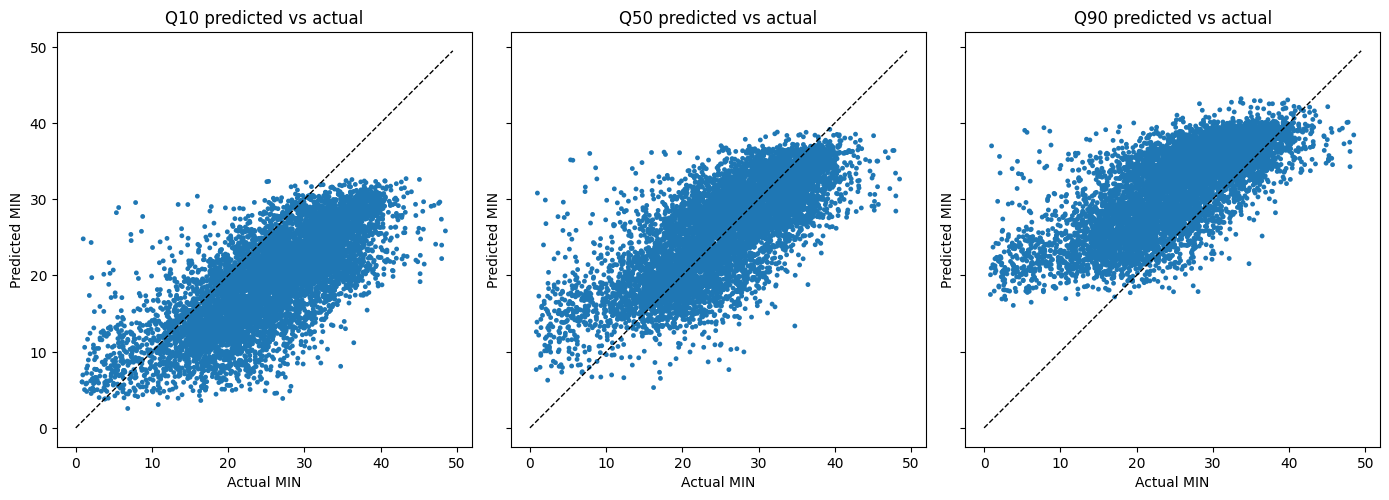

Q10 coverage: 0.12400052431511338
Q50 coverage: 0.5164503866823961
Q90 coverage: 0.8805872329269891
Coverage (10–90 interval): 75.66%


In [8]:
import matplotlib.pyplot as plt

y_true = y_val_min
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "coverage:", (y_true <= y_pred).mean())

# assumes you trained these quantiles and stored predictions
pred_low  = quantile_preds["q_0.10"]
pred_mid  = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_val_min >= pred_low) & (y_val_min <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

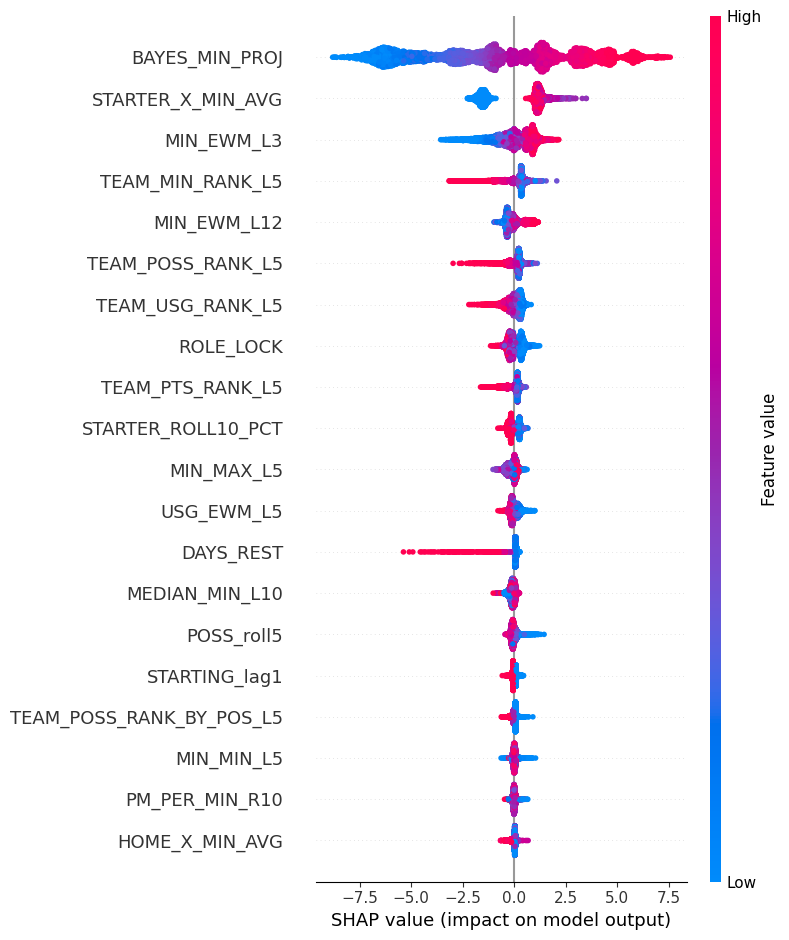

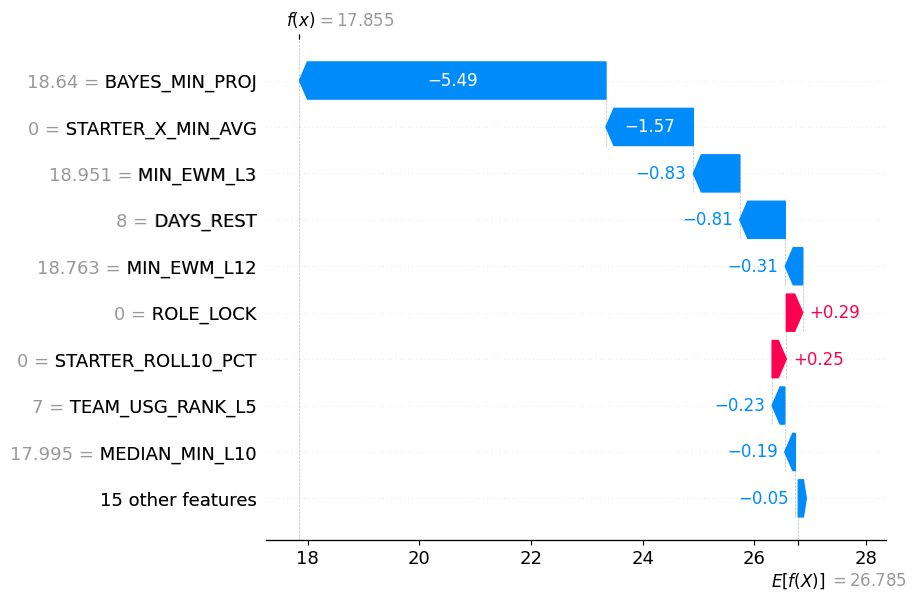

In [9]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_min)
shap.summary_plot(shap_values, X_val_min, feature_names=MIN_FEATURES)
shap.plots.waterfall(shap_values[1154])

In [30]:
import joblib
from pathlib import Path

out_dir = Path("models/min_quantile")  # or wherever you prefer
out_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "quantile_models": quantile_models,
    "feature_names": MIN_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, out_dir / "min_quantile_xgb.joblib")

['models/min_quantile/min_quantile_xgb.joblib']

## Model Analysis

In [10]:
target_date = pd.Timestamp("2026-03-26")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/raw/player_lines/NBA_DFS_20260326_151151.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()

In [24]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        features = min_pipeline(hist, name)
        min_arr = np.asarray(features, dtype=float).reshape(1, -1)

        # Use MODELS (XGBRegressor), not quantile_preds (numpy arrays)
        q50 = float(quantile_models["q_0.50"].predict(min_arr)[0])
        q10 = float(quantile_models["q_0.10"].predict(min_arr)[0])
        q90 = float(quantile_models["q_0.90"].predict(min_arr)[0])

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": q10,
            "PRED_MIN_Q50": q50,
            "PRED_MIN_Q90": q90,
            "PRED_MIN_RANGE_10_90": q90 - q10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_MIN_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] Mohamed Diawara: Feature shape mismatch, expected: 24, got 1
[SKIP] Herb Jones: Feature shape mismatch, expected: 24, got 1
[SKIP] Wendell Carter Jr: Feature shape mismatch, expected: 24, got 1
[SKIP] Jamal Cain: Feature shape mismatch, expected: 24, got 1


,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_MIN_RANGE_10_90
0,Karl-Anthony Towns,25.648333,32.329487,36.676544,11.028212
1,Jordan Clarkson,15.498128,23.315447,28.575623,13.077495
2,Mitchell Robinson,13.998179,18.879519,26.064560,12.066381
3,Kon Knueppel,23.662943,30.761688,35.616192,11.953249
4,Grant Williams,13.660977,20.712700,26.543419,12.882442


In [25]:
import numpy as np

def run_player_simulation(row, n_sims=10000):
    sim_min = np.random.triangular(
        left=row["PRED_MIN_Q10"] * 0.85,
        mode=row["PRED_MIN_Q50"],
        right=row["PRED_MIN_Q90"] * 1.15,
        size=n_sims,
    )
    sim_min = np.clip(sim_min, 0, 48)
    return sim_min

all_sims = {}
for i, row in preds_df.iterrows():
    if not np.isnan(row["PRED_MIN_Q50"]):
        all_sims[row["PLAYER_NAME"]] = run_player_simulation(row)

In [29]:
import numpy as np
import pandas as pd

rows = []
for name, arr in all_sims.items():
    arr = np.asarray(arr, dtype=float)
    m = float(np.mean(arr))
    rows.append({
        "PLAYER_NAME": name,
        "sim_mean": round(m, 2),
        "sim_std": round(float(np.std(arr, ddof=0)), 2),
        "sim_p10": round(float(np.percentile(arr, 10)), 2),
        "sim_p90": round(float(np.percentile(arr, 90)), 2),
        "sim_interquartile_range": round(float(np.percentile(arr, 75) - np.percentile(arr, 25)), 2),
        "sim_span_p90_p10": round(float(np.percentile(arr, 90) - np.percentile(arr, 10)), 2),
        "coef_of_variation": round(float(np.std(arr) / m), 2) if m > 1 else np.nan,
    })

vol_df = pd.DataFrame(rows)
vol_df.sort_values("sim_interquartile_range", ascending=True, inplace=True)
vol_df.head(5)

,PLAYER_NAME,sim_mean,sim_std,sim_p10,sim_p90,sim_interquartile_range,sim_span_p90_p10,coef_of_variation
5,Sion James,21.51,3.74,16.54,26.68,5.29,10.14,0.17
2,Mitchell Robinson,20.26,3.74,15.40,25.56,5.37,10.16,0.18
6,Ryan Kalkbrenner,19.83,3.77,14.83,25.03,5.45,10.20,0.19
25,CJ McCollum,30.16,3.86,24.80,35.24,5.50,10.43,0.13
4,Grant Williams,20.93,3.88,15.77,26.26,5.54,10.49,0.19
